# 1. Title Page
**Course Name & Code**: Civil Engineering Methods (Update accordingly)  
**Lab Title**: Linear Algebra Applications – Quadratic Spline Interpolation  
**Student Name & ID**: Rojyx L. Yangyang 2024-0118-4  
 

# 2. Objectives
To apply piecewise polynomial interpolation to solve a real-world engineering problem modeling the vertical deflection of a bridge beam. Specifically, this lab utilizes Python and the SymPy library to set up a system of linear equations to calculate the coefficients of Quadratic Splines and estimate beam deflection.

# 3. Problem Statement
A structural engineer is monitoring the vertical deflection of a bridge beam. Sensors placed at three points along the beam record the following deflections:
* Distance x = 0 m, Deflection y = 0 mm (the support)
* Distance x = 10 m, Deflection y = -15 mm
* Distance x = 20 m, Deflection y = 0 mm (the other support)

Task: Interpolate these points using the Quadratic Spline method.
1. Set up the system of linear equations mapping the piecewise intervals.
2. Solve for the coefficients of the spline functions.
3. Estimate the deflection at the center of the beam (x = 5m).

# 4. Mathematical Formulation
[cite_start]Based on the provided course material, quadratic splines are formulated by defining a distinct quadratic equation for each interval. 
* [cite_start]**Interval 1** ($0 \le x \le 10$): $f_1(x) = a_1 x^2 + b_1 x + c_1$ 
* [cite_start]**Interval 2** ($10 \le x \le 20$): $f_2(x) = a_2 x^2 + b_2 x + c_2$ 

[cite_start]To find the 6 unknown coefficients, 6 equations are required[cite: 26, 28]. They are established via the following conditions:
1. [cite_start]**Endpoint Connections:** Each quadratic spline goes through its two consecutive data points[cite: 18].
   * $f_1(0) = 0 \implies a_1(0)^2 + b_1(0) + c_1 = 0$
   * $f_1(10) = -15 \implies 100a_1 + 10b_1 + c_1 = -15$
   * $f_2(10) = -15 \implies 100a_2 + 10b_2 + c_2 = -15$
   * $f_2(20) = 0 \implies 400a_2 + 20b_2 + c_2 = 0$
2. [cite_start]**Derivative Continuity:** The first derivatives of the splines are continuous at the interior points ($x = 10$)[cite: 22].
   * [cite_start]$f'_1(10) = f'_2(10) \implies 20a_1 + b_1 = 20a_2 + b_2 \implies 20a_1 + b_1 - 20a_2 - b_2 = 0$ [cite: 23]
3. [cite_start]**Linear Assumption:** We can assume that the first spline is linear, that is $a_1 = 0$[cite: 27].

This creates the linear system $Ax = b$:
$$
\begin{bmatrix}
0 & 0 & 1 & 0 & 0 & 0 \\
100 & 10 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 100 & 10 & 1 \\
0 & 0 & 0 & 400 & 20 & 1 \\
20 & 1 & 0 & -20 & -1 & 0 \\
1 & 0 & 0 & 0 & 0 & 0 
\end{bmatrix}
\begin{bmatrix}
a_1 \\ b_1 \\ c_1 \\ a_2 \\ b_2 \\ c_2
\end{bmatrix}
=
\begin{bmatrix}
0 \\ -15 \\ -15 \\ 0 \\ 0 \\ 0
\end{bmatrix}
$$

--- 1. SETTING UP THE SYSTEM OF EQUATIONS ---
Solved Coefficients:
a1 = 0
a2 = 3/10
b1 = -3/2
b2 = -15/2
c1 = 0
c2 = 30

--- 2. FORMULATING THE SPLINES ---
Spline 1 (0 <= x <= 10): f1(x) = -3*x/2
Spline 2 (10 <= x <= 20): f2(x) = 3*x**2/10 - 15*x/2 + 30

--- 3. ESTIMATION ---
Estimated beam deflection at x = 5m is: -15/2 mm



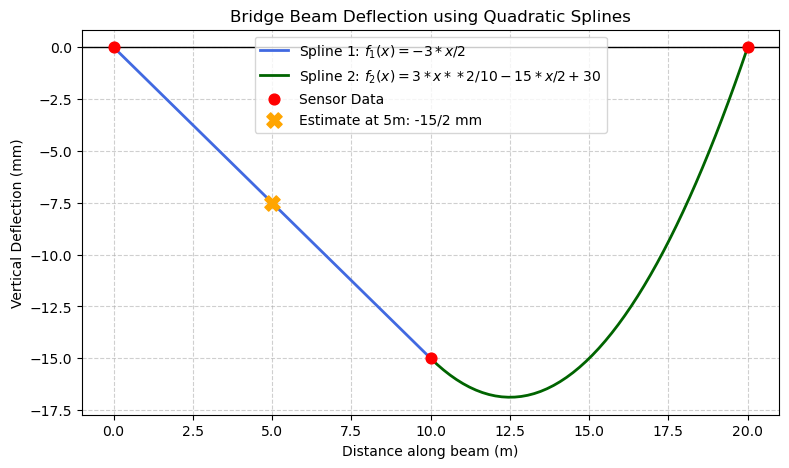

In [2]:
# 5. Python Implementation (Code)
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Define variables using SymPy
a1, b1, c1, a2, b2, c2 = sp.symbols('a1 b1 c1 a2 b2 c2')
x = sp.Symbol('x')

print("--- 1. SETTING UP THE SYSTEM OF EQUATIONS ---")
# Establish the 6 equations based on the constraints
eq1 = sp.Eq(c1, 0)
eq2 = sp.Eq(100*a1 + 10*b1 + c1, -15)
eq3 = sp.Eq(100*a2 + 10*b2 + c2, -15)
eq4 = sp.Eq(400*a2 + 20*b2 + c2, 0)
eq5 = sp.Eq(20*a1 + b1 - 20*a2 - b2, 0) # Continuous derivative at x=10
eq6 = sp.Eq(a1, 0)                      # Linear assumption for the first interval

# Solve the linear system
coeffs = sp.solve((eq1, eq2, eq3, eq4, eq5, eq6), (a1, b1, c1, a2, b2, c2))
print("Solved Coefficients:")
for key, val in coeffs.items():
    print(f"{key} = {val}")

print("\n--- 2. FORMULATING THE SPLINES ---")
# Formulate the piecewise functions
f1 = coeffs[a1]*x**2 + coeffs[b1]*x + coeffs[c1]
f2 = coeffs[a2]*x**2 + coeffs[b2]*x + coeffs[c2]

print(f"Spline 1 (0 <= x <= 10): f1(x) = {f1}")
print(f"Spline 2 (10 <= x <= 20): f2(x) = {f2}")

print("\n--- 3. ESTIMATION ---")
# Estimate deflection at x = 5m (This falls in the 1st interval, so use f1)
x_target = 5
deflection_at_5 = f1.subs(x, x_target)
print(f"Estimated beam deflection at x = {x_target}m is: {deflection_at_5} mm\n")

# 6. Results & Data Visualization
# Generate plotting data
x_vals_1 = np.linspace(0, 10, 50)
y_vals_1 = sp.lambdify(x, f1, 'numpy')(x_vals_1)

x_vals_2 = np.linspace(10, 20, 50)
y_vals_2 = sp.lambdify(x, f2, 'numpy')(x_vals_2)

# Plotting the graph
plt.figure(figsize=(9, 5))
plt.plot(x_vals_1, y_vals_1, label=f'Spline 1: $f_1(x) = {f1}$', color='royalblue', linewidth=2)
plt.plot(x_vals_2, y_vals_2, label=f'Spline 2: $f_2(x) = {f2}$', color='darkgreen', linewidth=2)

# Data points
plt.scatter([0, 10, 20], [0, -15, 0], color='red', zorder=5, s=60, label='Sensor Data')
plt.scatter(x_target, deflection_at_5, color='orange', zorder=5, marker='X', s=120, label=f'Estimate at 5m: {deflection_at_5} mm')

# Graph aesthetics
plt.title('Bridge Beam Deflection using Quadratic Splines')
plt.xlabel('Distance along beam (m)')
plt.ylabel('Vertical Deflection (mm)')
plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 6. Results
Solving the 6x6 linear system mathematically yields the following spline coefficients:
* **Spline 1** ($0 \le x \le 10$): $a_1 = 0.0$, $b_1 = -1.5$, $c_1 = 0.0$
* **Spline 2** ($10 \le x \le 20$): $a_2 = 0.3$, $b_2 = -7.5$, $c_2 = 30.0$

The two piecewise equations dictating the bridge curve are:
1. $f_1(x) = -1.5x$
2. $f_2(x) = 0.3x^2 - 7.5x + 30$

Because the target estimation of 5 meters falls perfectly within the domain of the first interval ($0 \le x \le 10$), the $f_1(x)$ spline was utilized. Substituting $x = 5$ evaluates the center beam deflection to be **-7.5 mm**. 

# 7. Discussion & Conclusion
* **Interpretation of Results:** Using Quadratic Splines generated two distinct mathematical profiles for the beam rather than a single continuous parabola. [cite_start]The estimate at 5m (-7.5 mm) acts strictly linearly because of the initial linear constraint assumption ($a_1 = 0$)[cite: 27]. 
* **Limitations of the Model:** The primary mathematical vulnerability of this specific implementation of Quadratic Splines is the forced assumption that the first spline segment is entirely linear. While establishing $a_1 = 0$ is a mathematically convenient way to reduce unknowns and fulfill the (3n) equation requirement, it physically assumes the bridge drops in a perfectly straight, linear line until the 10-meter mark, which is highly unrealistic for flexible bending beams. A Cubic Spline approach, which ensures continuous second derivatives without forcing a linear first interval, would offer a far superior physical approximation of a bending beam.